In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

# Global variables for drawing the line
drawing = False
line_start = None
line_end = None
scale = None

def draw_line(event, x, y, flags, param):
    global drawing, line_start, line_end
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        line_start = (x, y)
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        line_end = (x, y)
        cv2.line(param, line_start, line_end, (0, 255, 0), 2)
        cv2.imshow("Image", param)

def calculate_scale(image, real_distance):
    global line_start, line_end, scale
    print("Draw a line on the image and press any key when done.")
    cv2.imshow("Image", image)
    cv2.setMouseCallback("Image", draw_line, param=image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    if line_start and line_end:
        pixel_distance = np.sqrt((line_end[0] - line_start[0])**2 + (line_end[1] - line_start[1])**2)
        scale = real_distance / pixel_distance
        print(f"Scale calculated: {scale} units per pixel.")
    else:
        print("No line was drawn. Exiting.")
        exit()

def process_image(image_path, output_folder, real_distance):
    global scale
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return []

    # Prompt the user to draw a line and calculate the scale
    if scale is None:
        calculate_scale(image.copy(), real_distance)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect edges using Canny edge detection
    edges = cv2.Canny(gray, 100, 200)

    # Label connected components in the edge image
    num_labels, labels = cv2.connectedComponents(edges)

    # Create a blank output image
    output_image = np.zeros_like(image)

    edge_data = []  # To store data for each edge

    for label in range(1, num_labels):  # Skip the background label (0)
        # Extract points belonging to the current edge
        edge_points = np.argwhere(labels == label)

        # Convert pixel coordinates to real-world coordinates
        real_world_points = [(x * scale, y * scale) for x, y in edge_points]

        # Calculate the length of the edge
        edge_length = len(edge_points) * scale

        # Calculate the average contrast of the edge
        contrast_values = [gray[x, y] for x, y in edge_points]
        avg_contrast = np.mean(contrast_values)

        # Fit a polynomial curve to the real-world points
        real_world_points = np.array(real_world_points)
        x_coords = real_world_points[:, 1]  # Real-world x-coordinates
        y_coords = real_world_points[:, 0]  # Real-world y-coordinates
        if len(x_coords) > 2:  # Ensure there are enough points to fit a curve
            polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
            edge_data.append({
                "length": edge_length,
                "avg_contrast": avg_contrast,
                "coefficients": polynomial_coefficients,
                "x_coords": x_coords,
                "y_coords": y_coords
            })
            print(f"Edge {label}: Length = {edge_length:.2f} units, Avg Contrast = {avg_contrast:.2f}")
            print(f"Polynomial coefficients: {polynomial_coefficients}")
        else:
            print(f"Edge {label}: Not enough points to fit a curve.")

        # Draw the edge on the output image
        for x, y in edge_points:
            output_image[x, y] = (255, 255, 255)  # Draw edges in white

    # Save the output image
    output_path = os.path.join(output_folder, f"processed_{os.path.basename(image_path)}")
    cv2.imwrite(output_path, output_image)
    print(f"Processed and saved: {output_path}")

    return edge_data

def process_folder(folder_path, output_folder, real_distance):
    os.makedirs(output_folder, exist_ok=True)
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            process_image(os.path.join(folder_path, filename), output_folder, real_distance)

In [3]:
# Example usage
folder_path = 'test-cans/8.16x4.83/'  # Replace with your folder path
single_image_path = 'test-cans/8.16x4.83/pepsi.png'  # Replace with your single image path
output_folder = 'output-images/'  # Replace with your output folder path
real_distance = 8.16  # Replace with the real-world distance for the drawn line

# Process a folder of images
#process_folder(folder_path, output_folder, real_distance)

# Process a single image
process_image(single_image_path, output_folder, real_distance)

Draw a line on the image and press any key when done.
Scale calculated: 0.011192362667143995 units per pixel.
Edge 1: Length = 25.29 units, Avg Contrast = 113.22
Polynomial coefficients: [-3.89196663e-16  5.84958763e-15  2.22168399e+00]
Edge 2: Length = 8.19 units, Avg Contrast = 95.02
Polynomial coefficients: [  1.39913578 -20.09692772  72.59292562]
Edge 3: Length = 6.56 units, Avg Contrast = 123.17
Polynomial coefficients: [ 0.02815581 -0.31541817  1.87135301]
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Polynomial coefficients: [  -34.8103793    554.88311703 -2211.10604445]
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Polynomial coefficients: [  10.58632385 -169.21677353  676.35125522]
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Polynomial coefficients: [  48.7863101  -655.29875381 2200.6447664 ]
Edge 7: Length = 0.53 units, Avg Contrast = 117.28
Polynomial coefficients: [ -11.18694597  153.18947999 -524.19522624]
Edge 8: Length = 0.38 units, Avg Contrast = 109.65

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 125: Length = 0.03 units, Avg Contrast = 194.67
Polynomial coefficients: [0.01558881 0.06560284 0.27607828]
Edge 126: Length = 0.03 units, Avg Contrast = 193.00
Polynomial coefficients: [0.01203098 0.0576324  0.27607828]
Edge 127: Length = 0.03 units, Avg Contrast = 198.00
Polynomial coefficients: [0.00747462 0.04542664 0.27607828]
Edge 128: Length = 1.99 units, Avg Contrast = 68.70
Polynomial coefficients: [-1.43855429  2.65670827  0.04784997]
Edge 129: Not enough points to fit a curve.
Edge 130: Length = 0.04 units, Avg Contrast = 121.50
Polynomial coefficients: [-4.70033270e-13  1.02220213e-12  8.28234837e-01]
Edge 131: Length = 0.09 units, Avg Contrast = 149.12
Polynomial coefficients: [-41.79117041 109.56451613 -70.95777409]
Edge 132: Length = 0.98 units, Avg Contrast = 113.59
Polynomial coefficients: [  2.09949279 -33.45482755 134.22864213]
Edge 133: Not enough points to fit a curve.
Edge 134: Not enough points to fit a curve.
Edge 135: Length = 0.83 units, Avg Contrast = 22

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 323: Not enough points to fit a curve.
Edge 324: Length = 0.26 units, Avg Contrast = 120.65
Polynomial coefficients: [ -1.23863011  17.03343129 -56.75280001]
Edge 325: Not enough points to fit a curve.
Edge 326: Length = 0.75 units, Avg Contrast = 115.88
Polynomial coefficients: [ -0.92742871  12.57493872 -40.75206482]
Edge 327: Length = 0.06 units, Avg Contrast = 73.60
Polynomial coefficients: [0.01281982 0.0891036  0.61931073]
Edge 328: Length = 0.38 units, Avg Contrast = 91.68
Polynomial coefficients: [  0.72744619 -10.21165317  37.71113868]
Edge 329: Length = 0.17 units, Avg Contrast = 122.60
Polynomial coefficients: [  4.34938265 -62.08144743 223.40174348]
Edge 330: Length = 0.45 units, Avg Contrast = 98.97
Polynomial coefficients: [  1.73228064 -25.89191119  98.62293837]
Edge 331: Length = 0.03 units, Avg Contrast = 128.33
Polynomial coefficients: [0.01078533 0.08148148 0.61557995]
Edge 332: Length = 0.12 units, Avg Contrast = 101.55
Polynomial coefficients: [  -5.78210777  

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 487: Length = 2.34 units, Avg Contrast = 121.25
Polynomial coefficients: [ -0.37703961   5.33730095 -15.97596092]
Edge 488: Length = 1.59 units, Avg Contrast = 130.46
Polynomial coefficients: [ -0.95390773  14.07222614 -48.98787143]
Edge 489: Length = 0.26 units, Avg Contrast = 110.78
Polynomial coefficients: [  34.42267955 -497.31870111 1799.11961622]
Edge 490: Length = 0.35 units, Avg Contrast = 123.81
Polynomial coefficients: [ 0.34652653 -5.05806795 21.2700026 ]
Edge 491: Not enough points to fit a curve.
Edge 492: Not enough points to fit a curve.
Edge 493: Not enough points to fit a curve.
Edge 494: Not enough points to fit a curve.
Edge 495: Length = 0.04 units, Avg Contrast = 123.50
Polynomial coefficients: [0.01643966 0.12567106 0.9606778 ]
Edge 496: Not enough points to fit a curve.
Edge 497: Not enough points to fit a curve.
Edge 498: Not enough points to fit a curve.
Edge 499: Not enough points to fit a curve.
Edge 500: Length = 0.03 units, Avg Contrast = 194.33
Polyno

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 628: Length = 0.13 units, Avg Contrast = 159.17
Polynomial coefficients: [-3.98868929 11.27678571 -3.97388834]
Edge 629: Length = 0.40 units, Avg Contrast = 109.89
Polynomial coefficients: [ 0.18760722 -2.4111299  11.69090468]
Edge 630: Length = 0.08 units, Avg Contrast = 165.00
Polynomial coefficients: [ 7.16630778e-10  9.99999991e-01 -2.48470448e+00]
Edge 631: Length = 0.86 units, Avg Contrast = 231.27
Polynomial coefficients: [ 4.09081019e-15 -6.23696803e-14  3.98448111e+00]
Edge 632: Length = 0.15 units, Avg Contrast = 120.00
Polynomial coefficients: [  -5.917573     69.42623762 -199.55993281]
Edge 633: Length = 0.86 units, Avg Contrast = 185.27
Polynomial coefficients: [ 1.10190147e-15 -1.63847997e-14  4.00686583e+00]
Edge 634: Length = 0.59 units, Avg Contrast = 152.23
Polynomial coefficients: [-2.48010563  7.2706574  -1.21381501]
Edge 635: Length = 0.04 units, Avg Contrast = 170.75
Polynomial coefficients: [ 1.16854445e-12  1.00000000e+00 -2.46231979e+00]
Edge 636: Length =

[{'length': 25.29473962774543,
  'avg_contrast': 113.22433628318583,
  'coefficients': array([-3.89196663e-16,  5.84958763e-15,  2.22168399e+00]),
  'x_coords': array([0.        , 0.01119236, 0.02238473, ..., 8.18161711, 8.19280947,
         8.20400184]),
  'y_coords': array([0.        , 0.        , 0.        , ..., 4.44336798, 4.44336798,
         4.44336798])},
 {'length': 8.192809472349404,
  'avg_contrast': 95.01912568306011,
  'coefficients': array([  1.39913578, -20.09692772,  72.59292562]),
  'x_coords': array([6.6258787 , 6.63707106, 6.64826342, 6.65945579, 6.67064815,
         6.68184051, 6.69303287, 6.70422524, 6.7154176 , 6.72660996,
         6.73780233, 6.74899469, 6.76018705, 6.77137941, 6.78257178,
         6.79376414, 6.8049565 , 6.81614886, 6.82734123, 6.83853359,
         6.84972595, 6.86091831, 6.87211068, 6.88330304, 6.8944954 ,
         6.90568777, 6.91688013, 6.92807249, 6.93926485, 6.95045722,
         6.96164958, 6.97284194, 6.9840343 , 6.99522667, 7.00641903,
  

Edge 1: Length = 25.29 units, Avg Contrast = 113.22
Polynomial coefficients: [-3.89196663e-16  5.84958763e-15  2.22168399e+00]
Edge 2: Length = 8.19 units, Avg Contrast = 95.02
Polynomial coefficients: [  1.39913578 -20.09692772  72.59292562]
Edge 3: Length = 6.56 units, Avg Contrast = 123.17
Polynomial coefficients: [ 0.02815581 -0.31541817  1.87135301]
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Polynomial coefficients: [  -34.8103793    554.88311703 -2211.10604445]
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Polynomial coefficients: [  10.58632385 -169.21677353  676.35125522]
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Polynomial coefficients: [  48.7863101  -655.29875381 2200.6447664 ]
Edge 7: Length = 0.53 units, Avg Contrast = 117.28
Polynomial coefficients: [ -11.18694597  153.18947999 -524.19522624]
Edge 8: Length = 0.38 units, Avg Contrast = 109.65
Polynomial coefficients: [  17.7617257  -245.55151646  848.8728098 ]
Edge 9: Length = 0.08 units, Avg Contras

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 156: Length = 1.84 units, Avg Contrast = 229.37
Polynomial coefficients: [ -0.69762418   7.10221175 -16.72817094]
Edge 157: Not enough points to fit a curve.
Edge 158: Not enough points to fit a curve.
Edge 159: Length = 0.04 units, Avg Contrast = 202.25
Polynomial coefficients: [0.00997983 0.05707763 0.32644391]
Edge 160: Length = 0.03 units, Avg Contrast = 194.00
Polynomial coefficients: [0.00888564 0.0537037  0.32457852]
Edge 161: Length = 0.11 units, Avg Contrast = 66.70
Polynomial coefficients: [  -3.02576914   43.27527817 -153.72021359]
Edge 162: Not enough points to fit a curve.
Edge 163: Length = 0.03 units, Avg Contrast = 193.00
Polynomial coefficients: [-0.21347525  0.08887947  3.62463978]
Edge 164: Not enough points to fit a curve.
Edge 165: Length = 0.07 units, Avg Contrast = 204.50
Polynomial coefficients: [  -7.97737859   79.33928571 -196.25887882]
Edge 166: Length = 0.03 units, Avg Contrast = 182.00
Polynomial coefficients: [ 5.36674122e-12 -1.00000000e+00  3.861365

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 316: Length = 0.04 units, Avg Contrast = 207.00
Polynomial coefficients: [ 3.19967222e-13 -6.46765462e-13  1.73481621e+00]
Edge 317: Length = 0.43 units, Avg Contrast = 116.00
Polynomial coefficients: [  4.50527291 -72.54317569 293.79712273]
Edge 318: Not enough points to fit a curve.
Edge 319: Length = 1.26 units, Avg Contrast = 80.36
Polynomial coefficients: [-163.16559744  418.03759984 -265.67251735]
Edge 320: Length = 0.65 units, Avg Contrast = 114.12
Polynomial coefficients: [ 0.07847955 -1.05288782  5.30211454]
Edge 321: Length = 2.40 units, Avg Contrast = 114.97
Polynomial coefficients: [ -0.92808604  13.54826303 -47.61736192]
Edge 322: Length = 0.38 units, Avg Contrast = 124.68
Polynomial coefficients: [  0.74735045 -11.39570378  45.22863928]
Edge 323: Not enough points to fit a curve.
Edge 324: Length = 0.26 units, Avg Contrast = 120.65
Polynomial coefficients: [ -1.23863011  17.03343129 -56.75280001]
Edge 325: Not enough points to fit a curve.
Edge 326: Length = 0.75 uni

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 448: Length = 0.56 units, Avg Contrast = 123.82
Polynomial coefficients: [-0.22303424  3.08212472 -8.04834231]
Edge 449: Length = 0.54 units, Avg Contrast = 132.46
Polynomial coefficients: [  1.76231451 -24.81842455  89.95595763]
Edge 450: Length = 0.65 units, Avg Contrast = 116.55
Polynomial coefficients: [  0.92277013 -13.36288422  50.97101327]
Edge 451: Length = 0.22 units, Avg Contrast = 127.55
Polynomial coefficients: [  0.95615277 -14.22265548  55.46449784]
Edge 452: Length = 0.48 units, Avg Contrast = 136.81
Polynomial coefficients: [  0.80308152 -12.34418885  50.01322976]
Edge 453: Length = 0.57 units, Avg Contrast = 102.16
Polynomial coefficients: [  3.02497823 -46.32495542 179.99160787]
Edge 454: Length = 1.07 units, Avg Contrast = 138.22
Polynomial coefficients: [  -9.45086164  147.36068571 -571.75580186]
Edge 455: Length = 0.08 units, Avg Contrast = 126.86
Polynomial coefficients: [-2.33884249e-08  3.10969449e-07  2.58543474e+00]
Edge 456: Length = 0.07 units, Avg Cont

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 580: Length = 0.53 units, Avg Contrast = 96.74
Polynomial coefficients: [  1.04906911 -14.50970379  53.85040211]
Edge 581: Length = 0.65 units, Avg Contrast = 103.76
Polynomial coefficients: [  2.22247494 -29.72971974 103.23984409]
Edge 582: Length = 0.32 units, Avg Contrast = 96.93
Polynomial coefficients: [  1.64963764 -22.66341637  81.59261328]
Edge 583: Length = 0.07 units, Avg Contrast = 126.33
Polynomial coefficients: [  -6.76868486   94.59090908 -326.73270796]
Edge 584: Length = 0.04 units, Avg Contrast = 169.50
Polynomial coefficients: [-0.08773175  0.1851842   6.49572173]
Edge 585: Length = 0.04 units, Avg Contrast = 90.75
Polynomial coefficients: [  67.00998014 -918.75000008 3152.91094833]
Edge 586: Not enough points to fit a curve.
Edge 587: Not enough points to fit a curve.
Edge 588: Length = 0.29 units, Avg Contrast = 233.31
Polynomial coefficients: [  1.13869973 -18.31622887  77.46112724]
Edge 589: Length = 1.75 units, Avg Contrast = 208.50
Polynomial coefficients: [

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve


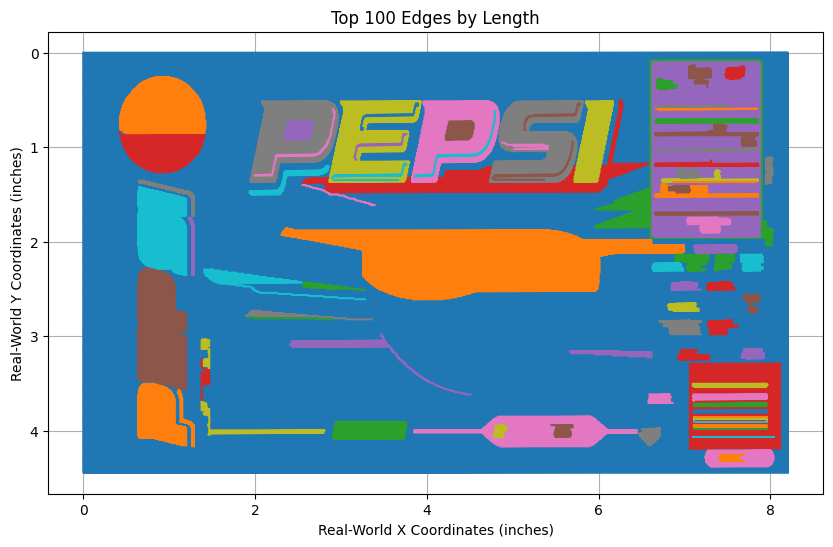

In [4]:
import matplotlib.pyplot as plt

# Process the image and get edge data
edge_data = process_image(single_image_path, output_folder, real_distance)

# Sort edges by length in descending order
sorted_edges = sorted(edge_data, key=lambda e: e["length"], reverse=True)

# Number of edges to plot
x = 100  # Replace with the desired number of edges to plot

# Plot the first x edges
plt.figure(figsize=(10, 6))
for i, edge in enumerate(sorted_edges[:x]):
    plt.plot(edge["x_coords"], edge["y_coords"], label=f"Edge {i+1} (Length: {edge['length']:.2f} inches)")

plt.title(f"Top {x} Edges by Length")
plt.xlabel("Real-World X Coordinates (inches)")
plt.ylabel("Real-World Y Coordinates (inches)")
plt.gca().invert_yaxis()  # Invert the y-axis to match the image coordinate system
#plt.legend()
plt.grid()
plt.show()

In [5]:
def segment_image_into_connected_color_clusters(image_path, color_threshold, output_folder, min_cluster_size=100):
    """
    Segments an image into clusters of connected pixels with similar colors.

    Args:
        image_path (str): Path to the input image.
        color_threshold (float): Threshold for color similarity (lower = stricter).
        output_folder (str): Path to save the segmented output images.
        min_cluster_size (int): Minimum number of pixels for a cluster to be saved.

    Returns:
        np.ndarray: The segmented image with outlined clusters.
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return

    # Convert the image to LAB color space (better for color similarity)
    image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # Create a blank canvas for the segmented image
    segmented_image = np.zeros_like(image)

    # Create a mask to track visited pixels
    visited = np.zeros(image_lab.shape[:2], dtype=bool)

    # Create an output folder
    os.makedirs(output_folder, exist_ok=True)

    # Cluster counter
    cluster_id = 0

    # Prepare for plotting
    fig, axes = plt.subplots(3, 5, figsize=(20, 15))  # Plot up to 15 clusters
    axes = axes.flatten()  # Flatten the 2D array into a 1D array
    plotted_clusters = 0

    # Iterate over each pixel in the image
    for y in range(image_lab.shape[0]):
        for x in range(image_lab.shape[1]):
            if visited[y, x]:
                continue

            # Start a new cluster
            cluster_mask = np.zeros(image_lab.shape[:2], dtype=bool)
            cluster_color = image_lab[y, x]

            # Perform region growing to find connected pixels with similar colors
            stack = [(y, x)]
            while stack:
                cy, cx = stack.pop()
                if visited[cy, cx]:
                    continue

                visited[cy, cx] = True
                cluster_mask[cy, cx] = True

                # Check neighbors
                for ny, nx in [(cy - 1, cx), (cy + 1, cx), (cy, cx - 1), (cy, cx + 1)]:
                    if 0 <= ny < image_lab.shape[0] and 0 <= nx < image_lab.shape[1]:
                        if not visited[ny, nx]:
                            neighbor_color = image_lab[ny, nx]
                            color_distance = np.linalg.norm(cluster_color - neighbor_color)
                            if color_distance < color_threshold:
                                stack.append((ny, nx))

            # Check if the cluster meets the minimum size requirement
            cluster_size = np.sum(cluster_mask)
            if cluster_size < min_cluster_size:
                continue  # Skip small clusters

            # Assign a random color to the cluster
            random_color = np.random.randint(0, 255, size=3, dtype=np.uint8)
            segmented_image[cluster_mask] = random_color

            # Save the cluster as an individual image
            cluster_image = np.zeros_like(image)
            cluster_image[cluster_mask] = image[cluster_mask]
            cluster_path = os.path.join(output_folder, f"cluster_{cluster_id + 1}.jpg")
            cv2.imwrite(cluster_path, cluster_image)
            print(f"Cluster {cluster_id + 1} saved to: {cluster_path}")

            # Plot the cluster (up to 15 clusters)
            if plotted_clusters < len(axes):
                axes[plotted_clusters].imshow(cv2.cvtColor(cluster_image, cv2.COLOR_BGR2RGB))
                axes[plotted_clusters].set_title(f"Cluster {cluster_id + 1}")
                axes[plotted_clusters].axis("off")
                plotted_clusters += 1

            cluster_id += 1

    # Save the final segmented image
    segmented_image_path = os.path.join(output_folder, "segmented_image.jpg")
    cv2.imwrite(segmented_image_path, segmented_image)
    print(f"Segmented image saved to: {segmented_image_path}")

    # Show the plot
    plt.tight_layout()
    plt.show()

    return segmented_image

Cluster 1 saved to: output-images-colors\cluster_1.jpg
Cluster 2 saved to: output-images-colors\cluster_2.jpg
Cluster 3 saved to: output-images-colors\cluster_3.jpg
Cluster 4 saved to: output-images-colors\cluster_4.jpg
Cluster 5 saved to: output-images-colors\cluster_5.jpg
Cluster 6 saved to: output-images-colors\cluster_6.jpg
Cluster 7 saved to: output-images-colors\cluster_7.jpg
Cluster 8 saved to: output-images-colors\cluster_8.jpg
Cluster 9 saved to: output-images-colors\cluster_9.jpg
Cluster 10 saved to: output-images-colors\cluster_10.jpg
Cluster 11 saved to: output-images-colors\cluster_11.jpg
Cluster 12 saved to: output-images-colors\cluster_12.jpg
Cluster 13 saved to: output-images-colors\cluster_13.jpg
Cluster 14 saved to: output-images-colors\cluster_14.jpg
Segmented image saved to: output-images-colors\segmented_image.jpg


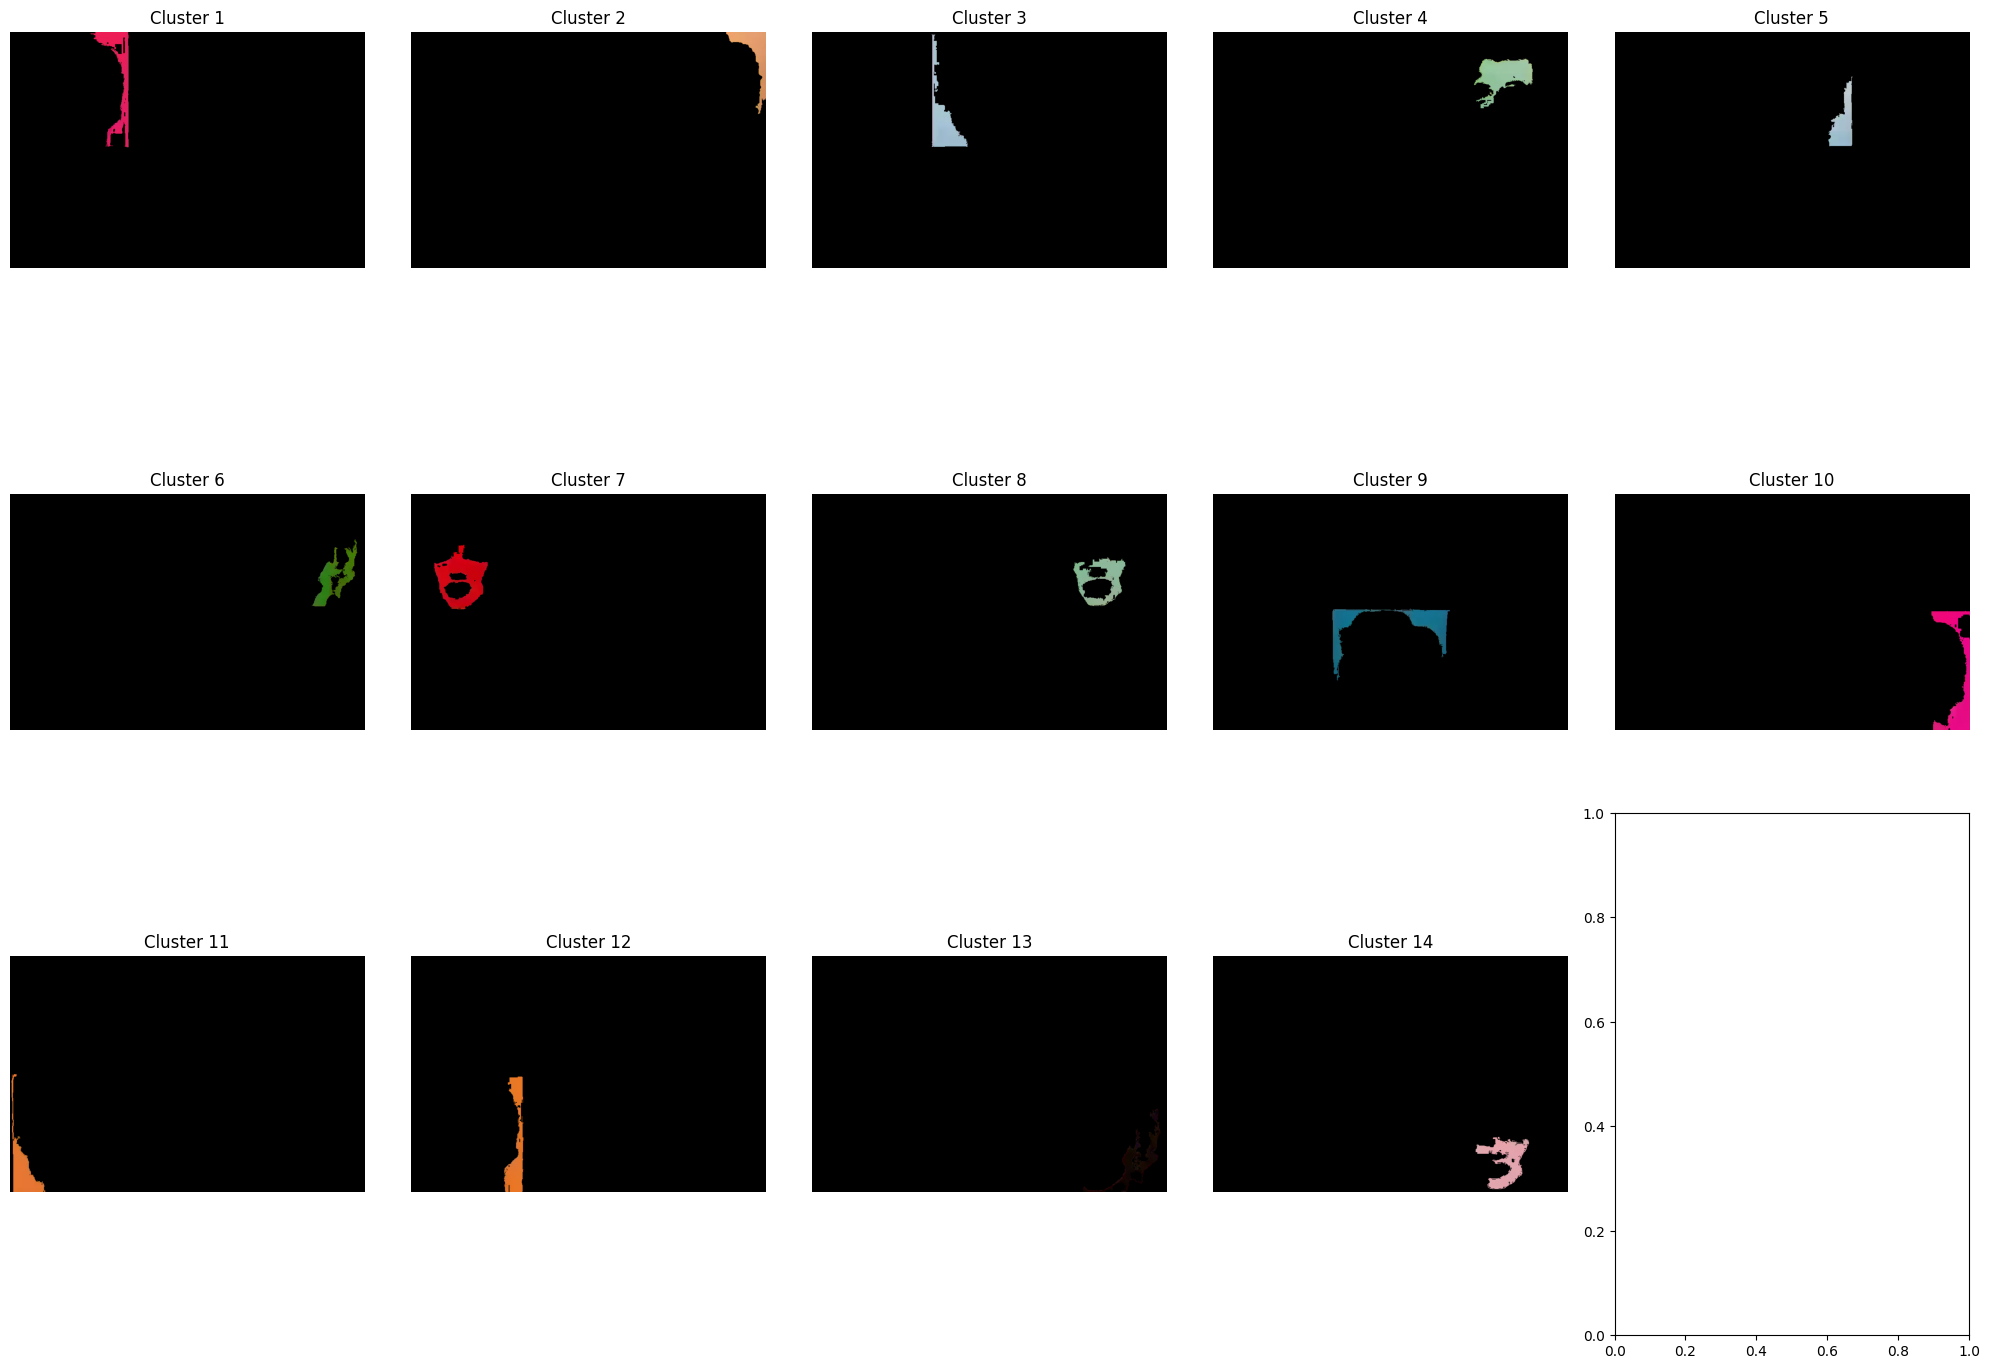

In [ ]:
# Example usage
image_path = "test-images/mm.png"  # Replace with your image path
output_folder = "output-images-colors"  # Replace with your output folder path
color_threshold = 30.0  # Adjust for stricter or looser color similarity
min_cluster_size = 5000  # Minimum size of clusters to save

segmented_image = segment_image_into_connected_color_clusters(image_path, color_threshold, output_folder, min_cluster_size)

In [ ]:
import cv2
import numpy as np
from math import atan2, degrees, pi
import os

def create_mosaic_from_polynomial_curves(small_image_path, small_image_width, large_image_path, large_image_width, max_small_images, output_path, process_image_function):
    """
    Creates a mosaic by pasting a smaller image repeatedly along the polynomial curves of a larger image's edges.

    Args:
        small_image_path (str): Path to the smaller image.
        small_image_width (float): Width of the smaller image in inches.
        large_image_path (str): Path to the larger image.
        large_image_width (float): Width of the larger image in inches.
        max_small_images (int): Maximum number of smaller images to use.
        output_path (str): Path to save the resulting mosaic image.
        process_image_function (function): Function to process the larger image and extract polynomial curves.

    Returns:
        None
    """
    # Load the smaller and larger images
    small_image = cv2.imread(small_image_path, cv2.IMREAD_UNCHANGED)
    large_image = cv2.imread(large_image_path, cv2.IMREAD_UNCHANGED)

    if small_image is None or large_image is None:
        print("Failed to load one or both images.")
        return

    # Calculate the scale (pixels per inch) for both images
    small_image_scale = small_image.shape[1] / small_image_width
    large_image_scale = large_image.shape[1] / large_image_width

    # Resize the smaller image to match the scale of the larger image
    scale_factor = large_image_scale / small_image_scale
    resized_small_image = cv2.resize(small_image, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)

    # Use the process_image function to extract polynomial curves from the larger image
    edge_data = process_image_function(large_image_path, output_folder="output_folder_for_edges", real_distance=large_image_width)

    # Create a blank canvas for the mosaic
    canvas = np.zeros_like(large_image)

    # Iterate through the polynomial curves
    small_image_count = 0
    for edge in edge_data:
        if small_image_count >= max_small_images:
            break

        # Extract the polynomial coefficients and curve points
        polynomial_coefficients = edge["coefficients"]
        x_coords = np.linspace(min(edge["x_coords"]), max(edge["x_coords"]), 100)
        y_coords = np.polyval(polynomial_coefficients, x_coords)

        # Iterate through the curve points and paste the smaller image
        for i in range(len(x_coords) - 1):
            if small_image_count >= max_small_images:
                break

            # Calculate the angle of rotation based on the curve's slope
            dx = x_coords[i + 1] - x_coords[i]
            dy = y_coords[i + 1] - y_coords[i]
            angle = degrees(atan2(dy, dx))

            # Rotate the smaller image
            h, w, _ = resized_small_image.shape
            rotation_matrix = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
            rotated_small_image = cv2.warpAffine(resized_small_image, rotation_matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

            # Calculate the position to paste the smaller image
            x = int(x_coords[i] - w // 2)
            y = int(y_coords[i] - h // 2)

            # Ensure the smaller image stays within the canvas bounds
            x_start = max(0, x)
            y_start = max(0, y)
            x_end = min(canvas.shape[1], x + w)
            y_end = min(canvas.shape[0], y + h)

            # Crop the rotated image if it goes out of bounds
            cropped_small_image = rotated_small_image[:y_end - y_start, :x_end - x_start]

            # Paste the smaller image onto the canvas
            canvas[y_start:y_end, x_start:x_end] = cropped_small_image

            small_image_count += 1

    # Save the resulting mosaic
    cv2.imwrite(output_path, canvas)
    print(f"Mosaic saved to: {output_path}")

In [14]:
# Example usage
small_image_path = "test-cans/8.16x4.83/pepsi.png"
small_image_width = 8.16  # Width of the smaller image in inches
large_image_path = "test-images/muhammed.png"
large_image_width = 240  # Width of the larger image in inches
max_small_images = 5000  # Maximum number of smaller images to use
output_path = "output_mosaic.jpg"

# Specify a valid output folder for edge processing
output_folder = "output_folder_for_edges"
os.makedirs(output_folder, exist_ok=True)

# Debugging: Test process_image independently
print("Testing process_image...")
edge_data = process_image(large_image_path, output_folder, large_image_width)
if not edge_data:
    print("No edge data returned. Check the process_image function.")
else:
    print(f"Edge data successfully returned: {len(edge_data)} edges found.")

# Debugging: Test create_mosaic_from_polynomial_curves
print("Creating mosaic...")
create_mosaic_from_polynomial_curves(
    small_image_path,
    small_image_width,
    large_image_path,
    large_image_width,
    max_small_images,
    output_path,
    lambda image_path, output_folder, real_distance: process_image(image_path, output_folder, real_distance)  # Use the valid output_folder
)
print("Mosaic creation complete.")

Testing process_image...
Edge 1: Length = 0.06 units, Avg Contrast = 65.00
Polynomial coefficients: [-10.08752389  15.11290323  -5.64889375]
Edge 2: Length = 0.67 units, Avg Contrast = 63.03
Polynomial coefficients: [ 3.08702379 -5.05454761  2.10188948]
Edge 3: Length = 0.84 units, Avg Contrast = 74.16
Polynomial coefficients: [-1.30290175  2.21955791 -0.75588955]
Edge 4: Length = 0.07 units, Avg Contrast = 36.17
Polynomial coefficients: [0.041315   0.04022989 0.03917327]
Edge 5: Length = 1.10 units, Avg Contrast = 73.86
Polynomial coefficients: [ 10.44377621 -12.7332864    4.37001007]
Edge 6: Length = 0.10 units, Avg Contrast = 55.00
Polynomial coefficients: [-3.72277667  6.19166667 -2.34778461]
Edge 7: Length = 1.13 units, Avg Contrast = 91.82
Polynomial coefficients: [ 1.04186057 -1.68785647  0.9301819 ]
Edge 8: Not enough points to fit a curve.
Edge 9: Length = 1.10 units, Avg Contrast = 92.20
Polynomial coefficients: [-4.04949664  5.70597168 -1.60895394]
Edge 10: Length = 0.19 uni

C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_37672\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Mosaic saved to: output_mosaic.jpg
Mosaic creation complete.
